In [10]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
import numpy as np

# ===== Cấu hình =====
input_base_dir = "/kaggle/input/valid-data"       # folder gốc
output_base_dir = "valid-augment"  # folder lưu ảnh augment
os.makedirs(output_base_dir, exist_ok=True)

# Thiết lập augmentation (tỉ lệ an toàn cho MRI/CT)
datagen = ImageDataGenerator(
    rescale=1./255,            # chuẩn hóa pixel
    shear_range=0.05,          # biến dạng nhẹ
    zoom_range=0.1,            # zoom ±10%
    rotation_range=12,         # xoay ±12 độ
    width_shift_range=0.05,    # dịch ngang ±5%
    height_shift_range=0.05,   # dịch dọc ±5%
    horizontal_flip=True,      # lật ngang (chỉ khi không quan trọng trái-phải)
    brightness_range=[0.9, 1.1],  # điều chỉnh sáng nhẹ ±10%
    fill_mode='nearest'        # tránh viền đen
)

# Số lượng ảnh augment mỗi ảnh gốc
num_augmented = 3

# Lặp qua từng class folder
for class_folder in os.listdir(input_base_dir):
    input_class_dir = os.path.join(input_base_dir, class_folder)
    output_class_dir = os.path.join(output_base_dir, class_folder)
    os.makedirs(output_class_dir, exist_ok=True)

    for filename in os.listdir(input_class_dir):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(input_class_dir, filename)
            img = load_img(img_path)
            x = img_to_array(img)
            x = np.expand_dims(x, axis=0)

            prefix = os.path.splitext(filename)[0]
            i = 0
            for batch in datagen.flow(
                x,
                batch_size=1,
                save_to_dir=output_class_dir,
                save_prefix=prefix,
                save_format='jpg'
            ):
                i += 1
                if i >= num_augmented:
                    break

print("✅ Augmentation hoàn tất! Ảnh mới lưu trong:", output_base_dir)


✅ Augmentation hoàn tất! Ảnh mới lưu trong: valid-augment


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/15 | Train Loss: 0.7191 | Val Acc: 0.4750
Epoch 2/15 | Train Loss: 0.6710 | Val Acc: 0.4625
Epoch 3/15 | Train Loss: 0.6278 | Val Acc: 0.4938
Epoch 4/15 | Train Loss: 0.6166 | Val Acc: 0.4625
Epoch 5/15 | Train Loss: 0.6011 | Val Acc: 0.4813
Epoch 6/15 | Train Loss: 0.5639 | Val Acc: 0.5000
Epoch 7/15 | Train Loss: 0.5267 | Val Acc: 0.5375
Epoch 8/15 | Train Loss: 0.5181 | Val Acc: 0.5563
Epoch 9/15 | Train Loss: 0.4992 | Val Acc: 0.5500
Epoch 10/15 | Train Loss: 0.4847 | Val Acc: 0.5687
Epoch 11/15 | Train Loss: 0.4743 | Val Acc: 0.5625
Epoch 12/15 | Train Loss: 0.4584 | Val Acc: 0.5500
Epoch 13/15 | Train Loss: 0.4404 | Val Acc: 0.5687
Epoch 14/15 | Train Loss: 0.4372 | Val Acc: 0.6188
Epoch 15/15 | Train Loss: 0.4428 | Val Acc: 0.6062

✅ Confusion Matrix:
[[81 39]
 [26 94]]

✅ Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.68      0.71       120
           1       0.71      0.78      0.74       120

    accuracy  

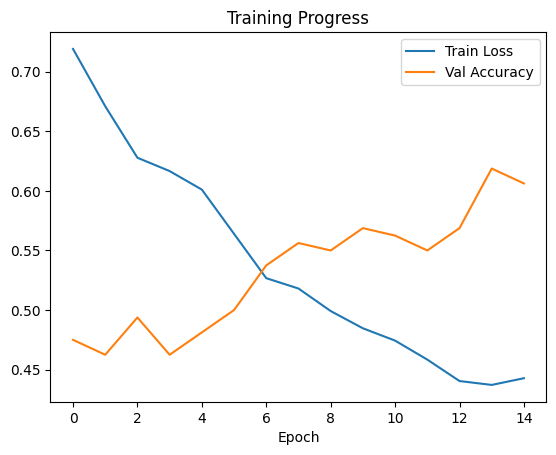


🔁 Số ảnh trùng giữa train và val: 0

📊 Phân phối nhãn trong validation: Counter({0: 20, 1: 20})
Tổng số ảnh validation: 40

📁 Số lớp trong validation: 2
Tên lớp: ['hemmorhage_data', 'non_hemmorhage_data']

👀 Nhãn thực tế (10 ảnh đầu): [0 0 0 0 0 0 0 0 0 0]
🤖 Nhãn dự đoán (10 ảnh đầu): [0 1 0 0 0 0 0 0 1 0]


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, ConcatDataset
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from collections import Counter
import os

# Chọn thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tiền xử lý ảnh: tăng cường dữ liệu cho train, chuẩn hóa cho valid/test
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load dữ liệu từ thư mục
train_set = datasets.ImageFolder("/kaggle/input/train-set/training_set/training_set", transform=train_transform)
train_aug = datasets.ImageFolder("/kaggle/input/train-augment/training_set_augmented/training_set_augmented", transform=train_transform)
train_data = ConcatDataset([train_set, train_aug])

val_set = datasets.ImageFolder("/kaggle/input/valid-data/validation_set/validation_set", transform=eval_transform)
val_aug = datasets.ImageFolder("/kaggle/input/valid-augment/validation_augmented/validation_augmented", transform=eval_transform)
val_data = ConcatDataset([val_set, val_aug])

test_set = datasets.ImageFolder("/kaggle/input/test-data/test_set/test_set", transform=eval_transform)
test_aug = datasets.ImageFolder("/kaggle/input/test-set-augmented/test_set_augmented/test_set_augmented", transform=eval_transform)
test_data = ConcatDataset([test_set, test_aug])

# Tạo DataLoader
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

#  Khởi tạo MobileNet V2 và freeze phần đặc trưng
model = models.mobilenet_v2(pretrained=True)
for param in model.features.parameters():
    param.requires_grad = False  # chỉ huấn luyện phần classifier
model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(model.last_channel, 2)  # 2 lớp: có u và không u
)
model = model.to(device)

#  Khai báo hàm mất mát và optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4)

#  Huấn luyện mô hình
num_epochs = 15
train_losses, val_accuracies = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(train_loader))

    # Đánh giá trên validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_accuracies.append(correct / total)
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_losses[-1]:.4f} | Val Acc: {val_accuracies[-1]:.4f}")

#  Đánh giá trên test set: in confusion matrix và report
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\n Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))
print("\n Classification Report:")
print(classification_report(all_labels, all_preds))

# Vẽ biểu đồ loss và accuracy
plt.plot(train_losses, label='Train Loss')
plt.plot(val_accuracies, label='Val Accuracy')
plt.xlabel('Epoch')
plt.title('Training Progress')
plt.legend()
plt.show()

#  Kiểm tra lý do val accuracy = 1.0
# Kiểm tra ảnh trùng giữa train và val
train_paths = set([os.path.basename(path[0]) for path in train_set.imgs])
val_paths = set([os.path.basename(path[0]) for path in val_set.imgs])
overlap = train_paths.intersection(val_paths)
print(f"\n Số ảnh trùng giữa train và val: {len(overlap)}")
if len(overlap) > 0:
    print(" Có thể dữ liệu bị trùng lặp giữa train và validation!")

# Kiểm tra phân phối nhãn trong validation
val_labels = [label for _, label in val_set.imgs]
val_distribution = Counter(val_labels)
print(f"\n Phân phối nhãn trong validation: {val_distribution}")
print(f"Tổng số ảnh validation: {len(val_set)}")

# Kiểm tra số lớp và tên lớp
print(f"\n Số lớp trong validation: {len(val_set.classes)}")
print(f"Tên lớp: {val_set.classes}")

# In thử nhãn thực và nhãn dự đoán từ validation
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        print(f"\n Nhãn thực tế (5 ảnh đầu): {labels[:5].cpu().numpy()}")
        print(f" Nhãn dự đoán (5 ảnh đầu): {preds[:5].cpu().numpy()}")
        break